In [1]:
import torch

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../scripts')
from functions import *

import seaborn as sns
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from livelossplot import PlotLosses
from sklearn.metrics import roc_auc_score
import copy
import wandb

In [3]:
df_sim = pd.read_hdf('../simulated-streams/simulated_patch.h5')
df_sim.head()


,μ_δ,μ_α,δ,α,b-r,g,ϕ,λ,μ_ϕcosλ,μ_λ,stream,α_wrapped
0,-11.000000,-4.833510,56.719927,172.465520,0.966099,18.886600,8.841160,0.281291,-2.098208,-11.830484,False,172.465520
1,2.533410,-26.788700,56.716618,172.410941,1.419800,17.494600,8.812834,0.271012,-26.632043,-3.845377,False,172.410941
2,-0.442341,-0.380034,56.719300,172.385308,1.229799,17.822701,8.798531,0.270310,-0.265391,-0.519287,False,172.385308
3,-16.743200,0.573184,56.719773,172.364918,0.819900,14.634200,8.787544,0.268140,4.488552,-16.140514,False,172.364918
4,-7.191590,-1.666070,56.701709,172.323133,0.758999,18.575701,8.769486,0.245202,0.064643,-7.381773,False,172.323133


In [4]:
df_sim.columns = ["pmdec", "pmra", "dec", "ra", "b-r", "g", 
                "rotra", "rotdec", "rotpmra", "rotpmdec", "stream", "ra_wrapped"]
print(len(df_sim))
df_sim.head()

886677


,pmdec,pmra,dec,ra,b-r,g,rotra,rotdec,rotpmra,rotpmdec,stream,ra_wrapped
0,-11.000000,-4.833510,56.719927,172.465520,0.966099,18.886600,8.841160,0.281291,-2.098208,-11.830484,False,172.465520
1,2.533410,-26.788700,56.716618,172.410941,1.419800,17.494600,8.812834,0.271012,-26.632043,-3.845377,False,172.410941
2,-0.442341,-0.380034,56.719300,172.385308,1.229799,17.822701,8.798531,0.270310,-0.265391,-0.519287,False,172.385308
3,-16.743200,0.573184,56.719773,172.364918,0.819900,14.634200,8.787544,0.268140,4.488552,-16.140514,False,172.364918
4,-7.191590,-1.666070,56.701709,172.323133,0.758999,18.575701,8.769486,0.245202,0.064643,-7.381773,False,172.323133


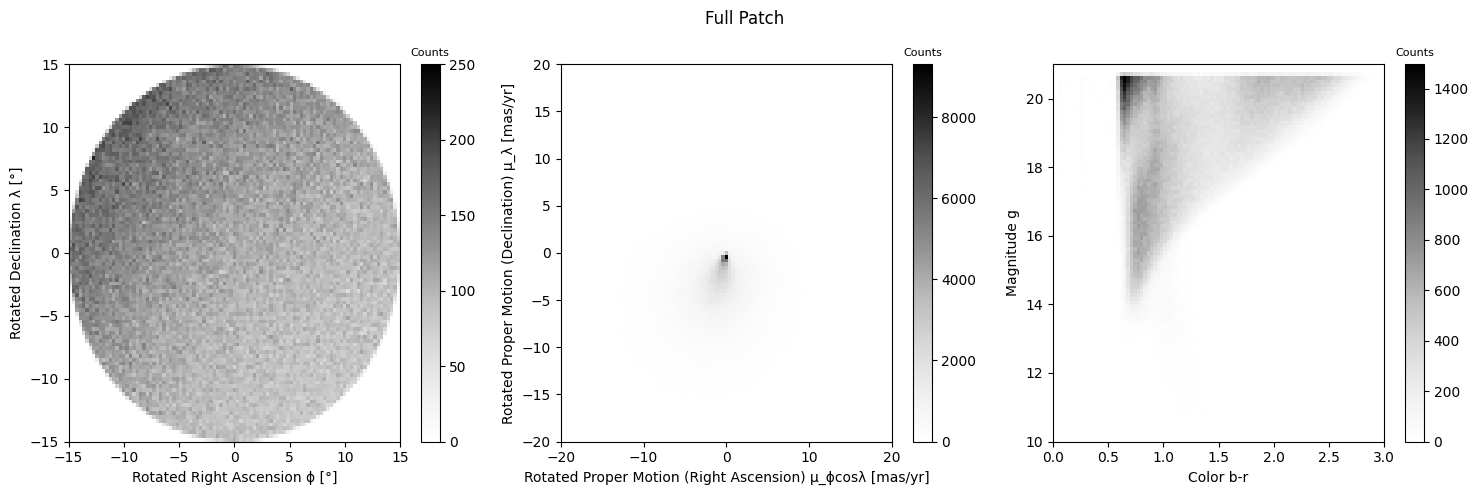

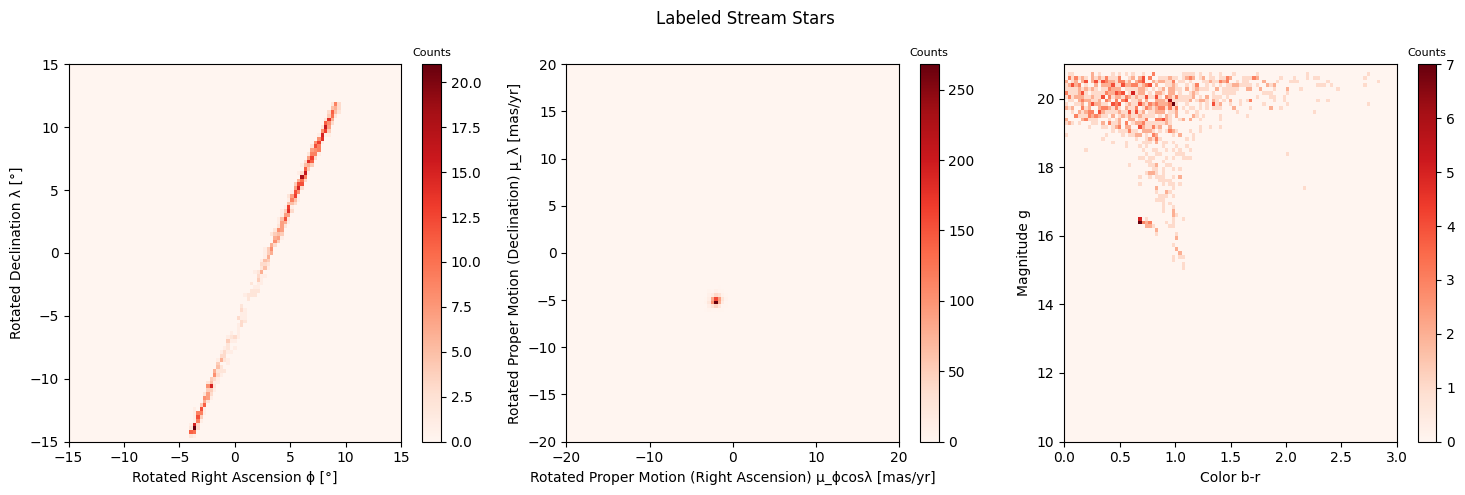

In [5]:
plot_data(df_sim)

In [6]:
df_stream = df_sim[df_sim['stream']==True]
print(f'Number of stream stars = {len(df_stream)}')

signal_parameter = df_stream['rotpmdec']
    
pm_median = np.median(signal_parameter)
pm_std = np.std(signal_parameter)

print('Sim Stream mu_lambda median = ', pm_median)
print('Sim Stream mu_lambda standard deviation = ', pm_std)

Number of stream stars = 1161
Sim Stream mu_lambda median =  -5.093735289333601
Sim Stream mu_lambda standard deviation =  5.00062926544632


In [7]:
sig_factor = 0.25
sb_factor = 0.5

sig_low = pm_median - sig_factor*pm_std
sig_high = pm_median + sig_factor*pm_std
sb_low = pm_median - sb_factor*pm_std
sb_high = pm_median + sb_factor*pm_std

print('Signal Region Range: ', sig_low, ' to ', sig_high)
print('Sideband Region Range: ', sb_low, ' to ', sig_low, ' and ', sig_high, ' to ', sb_high)  


Signal Region Range:  -6.343892605695181  to  -3.843577972972021
Sideband Region Range:  -7.594049922056762  to  -6.343892605695181  and  -3.843577972972021  to  -2.593420656610441


In [8]:
df_outer_region = df_sim[(df_sim['rotpmdec'] < sb_low) | (df_sim['rotpmdec'] > sb_high)]
len(df_outer_region)

539627

In [9]:
# sideband region = 0, signal region = 1

df_sim = df_sim[(df_sim['rotpmdec'] >= sb_low) & (df_sim['rotpmdec'] <= sb_high)]

df_sim['region_label'] = np.where((df_sim['rotpmdec'] >= sig_low) & (df_sim['rotpmdec'] <= sig_high), 1, 0)

df_sig_region = df_sim[df_sim['region_label']==1]
df_sb_region = df_sim[df_sim['region_label']==0]

df_sig_region_stream = df_sig_region[df_sig_region['stream']==True]
df_sig_region_background = df_sig_region[df_sig_region['stream']==False]

df_sb_region_stream = df_sb_region[df_sb_region['stream']==True]
df_sb_region_background = df_sb_region[df_sb_region['stream']==False]

print(f'Signal Region has {len(df_sig_region)} stars, {len(df_sig_region_stream)} stream and {len(df_sig_region_background)} background.')
print(f'Sideband Region has {len(df_sb_region)} stars, {len(df_sb_region_stream)} stream and {len(df_sb_region_background)} background.')      

Signal Region has 175716 stars, 1124 stream and 174592 background.
Sideband Region has 171334 stars, 3 stream and 171331 background.


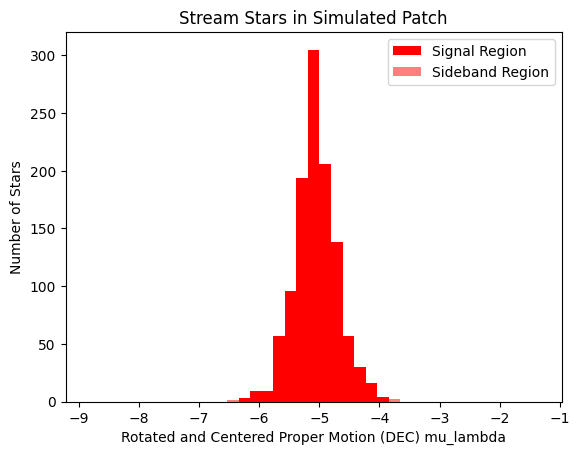

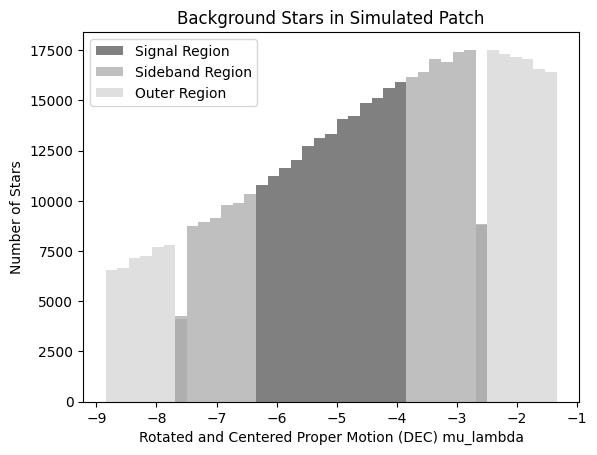

In [10]:
bins = np.linspace(sb_low - (sig_low - sb_low), sb_high + (sb_high - sig_high), 40)

plt.hist(df_sig_region_stream['rotpmdec'], label='Signal Region', color='red', alpha=1, bins=bins)
plt.hist(df_sb_region_stream['rotpmdec'], label='Sideband Region', color='red', alpha=0.5, bins=bins)
plt.xlabel('Rotated and Centered Proper Motion (DEC) mu_lambda')
plt.ylabel('Number of Stars')
plt.title('Stream Stars in Simulated Patch')
plt.legend()
plt.show()

plt.hist(df_sig_region_background['rotpmdec'], label='Signal Region', color='grey', alpha=1, bins=bins)
plt.hist(df_sb_region_background['rotpmdec'], label='Sideband Region', color='grey', alpha=0.5, bins=bins)
plt.hist(df_outer_region['rotpmdec'], label='Outer Region', color='grey', alpha=0.25, bins=bins)
plt.xlabel('Rotated and Centered Proper Motion (DEC) mu_lambda')
plt.ylabel('Number of Stars')
plt.title('Background Stars in Simulated Patch')
plt.legend()
plt.show()

In [11]:
print(f'Total number of stars within the signal and sideband regions is {len(df_sig_region) + len(df_sb_region)}')

Total number of stars within the signal and sideband regions is 347050


### k-folding

In [12]:
# X = input = training variables, not mu_lam
# y = region label

from sklearn.model_selection import StratifiedKFold


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
print(skf)
for i, (train_index, test_index) in enumerate(skf.split(df_sim[['b-r', 'g', 'rotra', 'rotdec', 'rotpmra']], df_sim['region_label'])):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

StratifiedKFold(n_splits=5, random_state=5, shuffle=True)
Fold 0:
  Train: index=[     0      1      2 ... 347045 347046 347049]
  Test:  index=[     5     12     22 ... 347042 347047 347048]
Fold 1:
  Train: index=[     0      1      2 ... 347046 347047 347048]
  Test:  index=[     6      9     11 ... 347038 347043 347049]
Fold 2:
  Train: index=[     0      3      4 ... 347047 347048 347049]
  Test:  index=[     1      2     10 ... 347015 347018 347022]
Fold 3:
  Train: index=[     1      2      4 ... 347047 347048 347049]
  Test:  index=[     0      3      8 ... 347044 347045 347046]
Fold 4:
  Train: index=[     0      1      2 ... 347047 347048 347049]
  Test:  index=[     4      7     26 ... 347036 347039 347041]


In [13]:
fold_stars = []

for fold_idx, (train_index, test_index) in enumerate(skf.split(df_sim[['b-r', 'g', 'rotra', 'rotdec', 'rotpmra']], df_sim['region_label'])):
    print(f"Fold {fold_idx}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

    fold_stars.append(test_index)

print(fold_stars) # fold stars is a list of 5 arrays, representing the 5 folds

fold_labels = np.arange(len(fold_stars))
print(fold_labels) # fold labels is an array of values 0-4, representing indices/labels of the 5 folds

Fold 0:
  Train: index=[     0      1      2 ... 347045 347046 347049]
  Test:  index=[     5     12     22 ... 347042 347047 347048]
Fold 1:
  Train: index=[     0      1      2 ... 347046 347047 347048]
  Test:  index=[     6      9     11 ... 347038 347043 347049]
Fold 2:
  Train: index=[     0      3      4 ... 347047 347048 347049]
  Test:  index=[     1      2     10 ... 347015 347018 347022]
Fold 3:
  Train: index=[     1      2      4 ... 347047 347048 347049]
  Test:  index=[     0      3      8 ... 347044 347045 347046]
Fold 4:
  Train: index=[     0      1      2 ... 347047 347048 347049]
  Test:  index=[     4      7     26 ... 347036 347039 347041]
[array([     5,     12,     22, ..., 347042, 347047, 347048],
      shape=(69410,)), array([     6,      9,     11, ..., 347038, 347043, 347049],
      shape=(69410,)), array([     1,      2,     10, ..., 347015, 347018, 347022],
      shape=(69410,)), array([     0,      3,      8, ..., 347044, 347045, 347046],
      shape=(694

In [14]:
## currently fold-star-indices has all stars, broken into 5 equal folds

## need to hold one fold as the test set

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

for test_idx in fold_labels:

    test_stars = fold_stars[test_idx]

    # cycles through remaining sets (minus the test set) for validation sets
    for val_idx in np.delete(fold_labels, test_idx):
        
        val_stars = fold_stars[val_idx]

        train_indices = np.delete(fold_labels, [test_idx, val_idx])
        train_stars = np.concatenate([fold_stars[train_idx] for train_idx in train_indices])

        # test_, val_, and train_ stars are now all 1, 1, and 3 folds respectively,
        # with the indices of the respective stars in a numpy array

        ## create data frames with indices
        df_train = df_sim.iloc[train_stars]
        df_val = df_sim.iloc[val_stars]
        df_test = df_sim.iloc[test_stars]

        train_x = df_train[['b-r', 'g', 'rotra', 'rotdec', 'rotpmra']]
        train_y = df_train['region_label'].to_numpy()

        val_x = df_val[['b-r', 'g', 'rotra', 'rotdec', 'rotpmra']]
        val_y = df_val['region_label'].to_numpy()

        test_x = df_test[['b-r', 'g', 'rotra', 'rotdec', 'rotpmra']]
        test_y = df_test['region_label'].to_numpy()
        test_y_true = df_test['stream'].to_numpy(dtype=int)

        break
    break

    # scale data
    # create tensors, datasets, dataloaders
    # train the model
        ## save weights -- wandb?? 
        ## repeat twice more, save weights with lowest validation score (best of n loops)

    ## repeat, changing validation to each of the 4 (already done in loop)

## evaluate each of the 4 models on the test set, average scores

print('Train')
print(train_x.head())
print(train_y)
print('-----------------')
print('Val')
print(val_x.head())
print(val_y)
print('-----------------')
print('Test')
print(test_x.head())
print(test_y)

Using device: cuda
Train
         b-r          g     rotra    rotdec   rotpmra
4   0.758999  18.575701  8.769486  0.245202  0.064643
5   2.083700  19.232500  8.824145  0.241586  0.546910
24  1.940100  18.496300  8.877031  0.142670  6.641763
31  1.864500  19.500401  8.779478  0.093162 -7.802644
55  1.116699  19.436199  9.501990  0.467208  2.906244
[0 0 1 ... 1 1 1]
-----------------
Val
         b-r          g     rotra    rotdec   rotpmra
16  1.037200  15.337300  8.698047  0.196227 -2.681365
23  1.095400  16.806900  8.872478  0.159303 -1.277069
26  0.633801  20.459299  8.767888  0.180589  0.084767
29  2.200901  19.355499  8.727563  0.166867  3.997160
34  0.725000  19.879400  9.555015  0.549601  0.676108
[0 0 0 ... 1 1 1]
-----------------
Test
         b-r          g     rotra    rotdec    rotpmra
10  2.558401  20.202400  8.708487  0.224766  16.382411
28  2.245699  19.194401  8.760769  0.163452   0.523997
53  0.607599  18.620100  9.500385  0.469381  -2.207290
54  1.364300  18.308300  9

In [7]:
class NeuralNetwork(nn.Module): # class groups variables and functions together
    def __init__(self, input_dim = 5, hidden_dim = 256, output_dim = 1, dropout=0.2): # create tool, parameters for recalling, call function is used after
        super().__init__() # access all methods, attributes, etc of class
        self.NeuralNetwork = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout),       
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout),       
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout),       
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.NeuralNetwork(x)




In [16]:
## scale data

scaler = StandardScaler()

train_x = scaler.fit_transform(train_x)
val_x = scaler.transform(val_x)
test_x = scaler.transform(test_x)
        
        
## create tensors, datasets, and loaders

train_x_tensor = torch.tensor(np.array(train_x))
train_y_tensor = torch.tensor(train_y)
    
val_x_tensor = torch.tensor(np.array(val_x))
val_y_tensor = torch.tensor(val_y)
    
test_x_tensor = torch.tensor(np.array(test_x))
test_y_tensor = torch.tensor(test_y)
test_y_true_tensor = torch.tensor(test_y_true)
    
train_dataset = TensorDataset(train_x_tensor, train_y_tensor)
val_dataset = TensorDataset(val_x_tensor, val_y_tensor)
test_dataset = TensorDataset(test_x_tensor, test_y_tensor, test_y_true_tensor)
    
train_loader = DataLoader(train_dataset, batch_size=10000, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=10000, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=10000, shuffle=False)

for inputs, labels in train_loader:
    print(inputs.shape, labels.shape)
    break


## initialize the model
    
model = NeuralNetwork(input_dim = 5, hidden_dim = 256, output_dim = 1, dropout=0.2).to(device)
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
early_stopping = EarlyStopping(patience=30, min_delta=0.0001)

torch.Size([10000, 5]) torch.Size([10000])


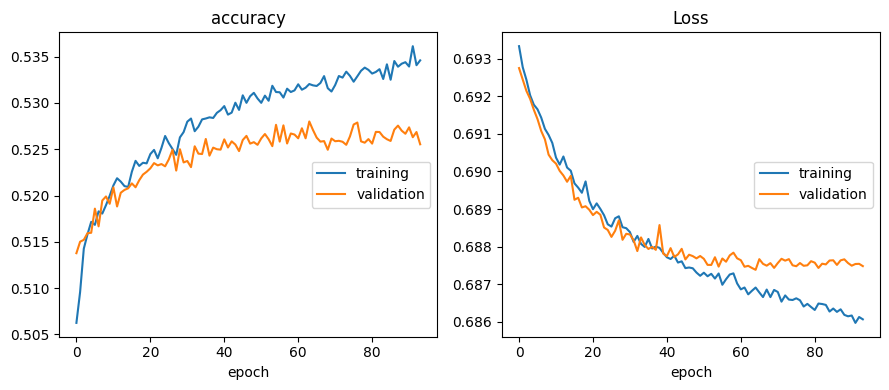

accuracy
	training         	 (min:    0.506, max:    0.536, cur:    0.535)
	validation       	 (min:    0.514, max:    0.528, cur:    0.526)
Loss
	training         	 (min:    0.686, max:    0.693, cur:    0.686)
	validation       	 (min:    0.687, max:    0.693, cur:    0.687)
Epoch 93, Loss: 0.6796
Epoch 93, Accuracy: 0.5255
Early stopping


<All keys matched successfully>

In [17]:
liveloss = PlotLosses(figsize=(9,4))

import wandb
wandb.init(project='simulated-1')

logs = {}

best_val_loss = float('inf')
patience = 30
patience_counter = 0

for epoch in range(100):

    # training
    model.train()
    total_train_loss = 0
    train_correct, counts = 0, 0
    for inputs, region_labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs = inputs.to(device).float()
        region_labels = region_labels.to(device).float()
        
        out = model(inputs).squeeze(1)  # forward pass
        loss = loss_fn(out, region_labels)  # compute loss
        loss.backward()  # backward pass
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

        predictions = (out > 0.5).float()
        train_correct += (predictions == region_labels).sum().item()
        counts += region_labels.size(0)

    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss'] = train_loss_per_batch

    train_accuracy = train_correct / counts
    logs['accuracy'] = train_accuracy

    wandb.watch(model, log="all", log_freq=100)


    # validation
    model.eval()
    total_val_loss = 0
    val_correct, counts = 0.0, 0
    for inputs, region_labels in val_loader:
        inputs = inputs.to(device).float()
        region_labels = region_labels.to(device).float()

        out = model(inputs).squeeze(1)  # forward pass
        loss = loss_fn(out, region_labels)  # compute loss
        total_val_loss += loss.item()

        predictions = (out > 0.5).float()
        val_correct += (predictions == region_labels).sum().item()
        counts += region_labels.size(0)

    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss'] = val_loss_per_batch

    val_accuracy = val_correct / counts
    logs['val_accuracy'] = val_accuracy
    
    # early stopping
    if val_loss_per_batch < best_val_loss:
        best_val_loss = val_loss_per_batch
        patience_counter = 0
        best_model = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping")
        break

    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item():.4f}')
    print(f'Epoch {epoch}, Accuracy: {val_accuracy:.4f}')

    wandb.log({"train_loss": train_loss_per_batch, "val_loss": val_loss_per_batch, "epoch": epoch})

model.load_state_dict(best_model) ## model parameters from epoch with the lowest validation loss

tensor([[ 2.7057,  0.9187,  1.2883, -0.1015,  3.5768],
        [ 2.0978,  0.3458,  1.2952, -0.1097,  0.4060],
        [-1.0870,  0.0194,  1.3929, -0.0686, -0.1401],
        ...,
        [-0.9484,  0.7959,  1.3241,  0.4285, -0.2201],
        [-0.7363,  0.9606,  1.3089,  0.4264, -0.1723],
        [-0.2609,  0.1329,  1.3057,  0.4090,  0.6046]], device='cuda:0')
tensor([[-1.1016,  0.4665,  1.2894,  0.3944, -0.0718],
        [-0.8800,  0.8116,  1.2803,  0.3870,  0.3454],
        [-0.4896,  0.0337,  1.2798,  0.3814, -0.1137],
        ...,
        [ 2.1790,  1.1431,  0.0906, -0.5745, -0.2592],
        [-0.9173,  0.8910,  0.0836, -0.5856, -0.0497],
        [ 0.3542,  1.1019,  0.0676, -0.4884, -0.6253]], device='cuda:0')
tensor([[ 0.5333,  0.8674,  0.0688, -0.4888,  0.3718],
        [ 1.6407,  0.6311,  0.0636, -0.4910, -1.4363],
        [ 0.1052, -0.7159,  0.0758, -0.5023, -1.2897],
        ...,
        [-0.4239, -0.4422,  1.3118, -0.3631, -0.9660],
        [ 0.7534, -0.3960,  1.3130, -0.3723, 

epoch,▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇███
train_loss,█▇▇▆▆▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
val_loss,█▇▅▅▅▄▃▃▃▃▂▂▂▂▂▂▂▁▂▁▁▂▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch,93
train_loss,0.68607
val_loss,0.68748


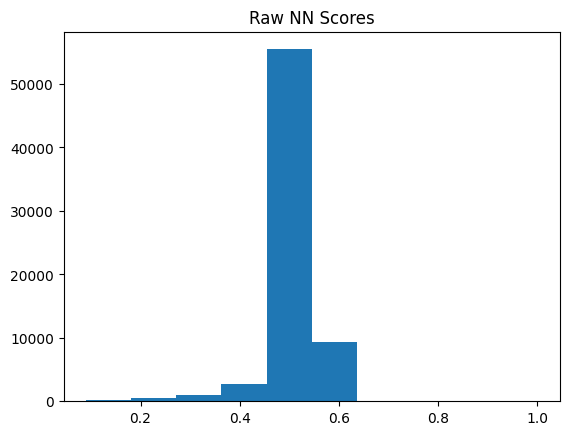

In [18]:
# evaluate on test set 
# run on test set
model.eval()
test_loss, test_correct, counts = 0.0, 0.0, 0
all_scores = []
all_region_labels = []
all_true_labels = []
raw_scores = []

with torch.no_grad():
    for inputs, region_labels, true_labels in test_loader:
        
        inputs = inputs.to(device).float()
        region_labels = region_labels.to(device).float()
        print(inputs)
        out = model(inputs).squeeze()
        raw_scores.extend(out.squeeze().cpu().numpy())
        loss = loss_fn(out, region_labels)
        test_loss += loss.item() * inputs.size(0)

        scores = (out > 0.5).float()
        all_scores.extend(scores.squeeze().cpu().numpy())
        
        all_region_labels.extend(region_labels.squeeze().cpu().numpy())
        all_true_labels.extend(true_labels.numpy())
            
        # Track counts
        test_correct += (scores == region_labels).sum().item()
        counts += region_labels.size(0)

all_scores = np.array(all_scores)
all_region_labels = np.array(all_region_labels)
all_true_labels = np.array(all_true_labels)
raw_scores = np.array(raw_scores)

print(' ')
print('----------------------------------------')
print(' ')

print(f"Average test loss: {test_loss/counts:.4f} | Test accuracy: {test_correct/counts:.4f}")
print(' ')

plt.hist(raw_scores)
plt.title('Raw NN Scores')

# calculate ROC-AUC score
auc_regions = roc_auc_score(all_region_labels, raw_scores)
print(' ')
print(f"Test ROC-AUC for fully supervised signal/sb region classifier: {auc_regions:.4f}")

auc_true = roc_auc_score(all_true_labels, raw_scores)
print(f"Test ROC-AUC for true background/stream labels: {auc_true:.4f}")

# calculate purity and completeness

true_pos = np.sum((all_scores == 1) & (all_true_labels == 1))
false_pos = np.sum((all_scores == 1) & (all_true_labels == 0))
true_neg = np.sum((all_scores == 0) & (all_true_labels == 0))
false_neg = np.sum((all_scores == 0) & (all_true_labels == 1))

print(' ')
print(f"TP = {true_pos}")
print(f"FP = {false_pos}")
print(f"FN = {false_neg}")
print(f"TN = {true_neg}")

purity = true_pos / (true_pos + false_pos)
completeness = true_pos / (true_pos + false_neg)
print(' ')
print(f'Purity = {purity}')
print(f'Completeness = {completeness}')

wandb.finish()

### explore full 100 sim stream df

In [8]:
df_allsims = pd.read_hdf('../simulated-streams/simulated-streams100.h5')

In [9]:
df_allsims.head()

,μ_δ,μ_α,δ,α,b-r,g,ϕ,λ,μ_ϕcosλ,μ_λ,stream,α_wrapped,file
0,-6.91689,1.18934,56.738241,173.716410,1.116699,19.436199,9.501990,0.467208,2.906244,-6.388399,False,173.716410,0
1,-9.30777,-1.48751,56.785184,173.616905,0.739000,18.930500,9.437339,0.498815,0.910470,-9.381807,False,173.616905,0
2,-8.84513,3.49865,56.721386,173.743575,1.346800,18.566999,9.520686,0.454691,5.632414,-7.665037,False,173.743575,0
3,-6.42498,-4.61974,56.650657,173.776438,2.400400,20.639000,9.556140,0.390884,-2.831004,-7.389708,False,173.776438,0
4,-8.33763,-3.67816,56.570386,173.611326,0.713100,17.377399,9.488593,0.290198,-1.454926,-8.996006,False,173.611326,0


In [11]:
df_allsims.columns=["pmdec", "pmra", "dec", "ra", "b-r", "g", 
                "rotra", "rotdec", "rotpmra", "rotpmdec", 'stream', 'ra_wrapped','file']
df_allsims.head()

,pmdec,pmra,dec,ra,b-r,g,rotra,rotdec,rotpmra,rotpmdec,stream,ra_wrapped,file
0,-6.91689,1.18934,56.738241,173.716410,1.116699,19.436199,9.501990,0.467208,2.906244,-6.388399,False,173.716410,0
1,-9.30777,-1.48751,56.785184,173.616905,0.739000,18.930500,9.437339,0.498815,0.910470,-9.381807,False,173.616905,0
2,-8.84513,3.49865,56.721386,173.743575,1.346800,18.566999,9.520686,0.454691,5.632414,-7.665037,False,173.743575,0
3,-6.42498,-4.61974,56.650657,173.776438,2.400400,20.639000,9.556140,0.390884,-2.831004,-7.389708,False,173.776438,0
4,-8.33763,-3.67816,56.570386,173.611326,0.713100,17.377399,9.488593,0.290198,-1.454926,-8.996006,False,173.611326,0


In [12]:
df_allsims.to_hdf(f'../simulated-streams/simulated-data/simulated-streams100.h5', key=f'data', mode='w')